In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from scipy.stats import t
import ast

In [69]:
df_original = pd.read_csv("created_files/results_test_list_random_order.csv")

In [70]:
df_original["confusion_matrix"] = df_original["confusion_matrix"].apply(ast.literal_eval)
df_original = df_original.drop(['test_data_time', 'test_time'], axis=1)
df_original["total_load_time"] = df_original["load_time"] + df_original["network_time"]
df_original["total_time"] = df_original["total_load_time"] + df_original["forward_time"]

In [71]:
df_original.head()

,net_name,network_time,forward_time,load_time,accuracy,confusion_matrix,total_load_time,total_time
0,dilated_lenet5,0.000888,0.277716,1.497419,98.94,"[[975, 0, 0, 0, 0, 0, 1, 1, 3, 0], [0, 1130, 1...",1.498307,1.776024
1,400-300-10,0.002034,0.086717,1.295269,98.34,"[[973, 0, 1, 0, 0, 0, 2, 1, 2, 1], [0, 1122, 3...",1.297303,1.384020
2,network3,0.005548,0.573622,1.305918,99.32,"[[978, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 1132, 1...",1.311467,1.885088
3,dropout_simple_CNN,0.001009,0.364291,1.560744,99.37,"[[975, 0, 1, 0, 0, 0, 3, 1, 0, 0], [0, 1133, 0...",1.561752,1.926043
4,128-10,0.000743,0.044912,1.267283,98.07,"[[970, 0, 1, 0, 0, 2, 2, 1, 3, 1], [0, 1123, 3...",1.268026,1.312938


In [72]:
df_means = df_original[["net_name", "network_time", "forward_time", "load_time", "total_load_time", "total_time", "accuracy"]].groupby("net_name").mean()

In [73]:
df_means

,network_time,forward_time,load_time,total_load_time,total_time,accuracy
net_name,,,,,,
128-10,0.000680,0.040027,1.195040,1.195720,1.235748,98.07
400-10,0.001587,0.058547,1.202348,1.203935,1.262481,98.35
400-300-10,0.001906,0.077256,1.200203,1.202109,1.279365,98.34
CNN_with_BN,0.009390,0.811646,1.300128,1.309519,2.121164,99.38
dilated_lenet5,0.000888,0.266199,1.473652,1.474540,1.740740,98.94
dropout_lenet5,0.001067,0.274277,1.475977,1.477044,1.751321,99.19
dropout_simple_CNN,0.001163,0.334438,1.481950,1.483113,1.817551,99.37
lenet1,0.000492,0.193061,1.690783,1.691275,1.884335,98.44
lenet4,0.000825,0.232181,1.457211,1.458037,1.690217,99.09


In [74]:
alpha = 0.05

numeric_cols = df_original.select_dtypes(include=np.number).columns

results = {}

for col in numeric_cols:
    ic_list = []

    for net_name, group in df_original.groupby("net_name"):
        n = len(group)
        s = group[col].std(ddof=1)

        # quantile de Student
        t_crit = t.ppf(1 - alpha / 2, df=n - 1)

        margin = t_crit * s / np.sqrt(n)

        ic_list.append(margin)

    results[col] = ic_list

df_ic = pd.DataFrame(results, index = df_original["net_name"].unique())

In [75]:
df_ic

,network_time,forward_time,load_time,accuracy,total_load_time,total_time
dilated_lenet5,0.000064,0.001827,0.030050,1.071573e-14,0.030063,0.031802
400-300-10,0.000230,0.002102,0.028509,0.000000e+00,0.028610,0.030464
network3,0.000192,0.003069,0.031035,0.000000e+00,0.031071,0.033851
dropout_simple_CNN,0.002354,0.011847,0.020038,0.000000e+00,0.020695,0.030984
128-10,0.000173,0.005256,0.024315,1.071573e-14,0.024281,0.028320
lenet1,0.000111,0.007163,0.045337,1.071573e-14,0.045328,0.051431
simplified_lenet5,0.000112,0.011474,0.030672,0.000000e+00,0.030651,0.041591
dropout_lenet5,0.000038,0.005269,0.028048,1.071573e-14,0.028065,0.031871
lenet4,0.000173,0.007150,0.028953,0.000000e+00,0.028931,0.035227
lenet5,0.000084,0.005459,0.021382,0.000000e+00,0.021419,0.026081


In [76]:
def pareto_front(df, time_feature):
    pareto = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if (
                other['accuracy'] >= row['accuracy'] and
                other[time_feature] <= row[time_feature] and
                (other['accuracy'] > row['accuracy'] or
                 other[time_feature] < row[time_feature])
            ):
                dominated = True
                break
        if not dominated:
            pareto.append(i)
    return df.loc[pareto]

In [77]:
def plot_time_vs_accuracy(time_feature):
    plt.figure(figsize=(10, 6))
    plt.scatter(df_means[time_feature], df_means["accuracy"], color="tab:blue", s=80)

    #nommage des points
    for net_name, row in df_means.iterrows():
        plt.annotate(net_name,
                    (row[time_feature], row["accuracy"]),
                    textcoords="offset points",
                    xytext=(5, 5),
                    ha="left",
                    fontsize=9)

    #intervalles de confiance
    plt.errorbar(
        df_means[time_feature],
        df_means["accuracy"],
        xerr= df_ic[time_feature],
        fmt='none',
        capsize=4
    )

    #courbe de pareto
    pareto_df = pareto_front(df_means, time_feature)
    pareto_df = pareto_df.sort_values(time_feature)
    plt.plot(pareto_df[time_feature], pareto_df['accuracy'], color='red', label="Front de Pareto")

    plt.title(time_feature+" vs accuracy par modèle")
    plt.xlabel(time_feature+" (s)")
    plt.ylabel("accuracy (%)")
    plt.gca().invert_xaxis()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

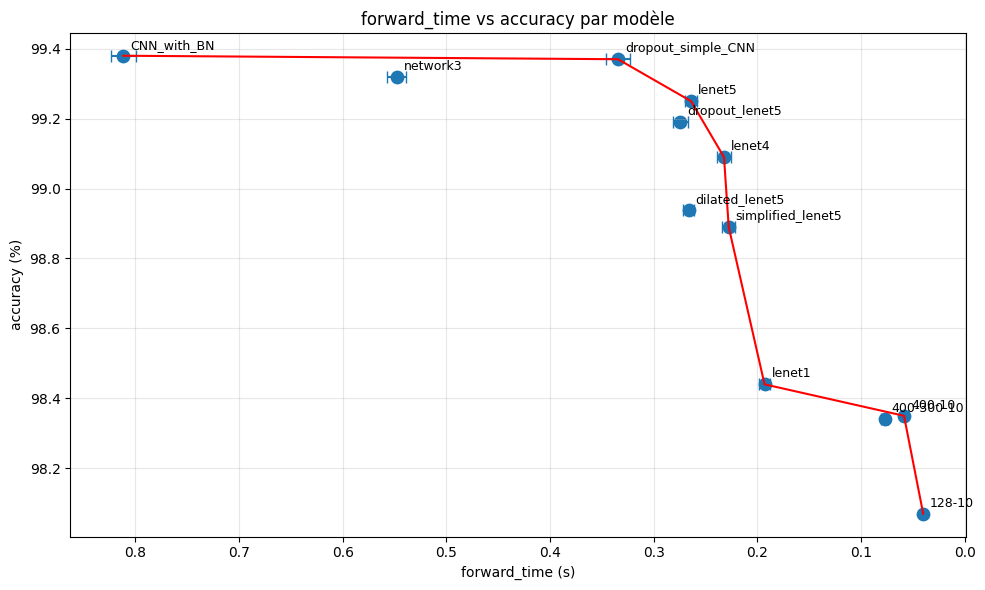

In [78]:
plot_time_vs_accuracy("forward_time")

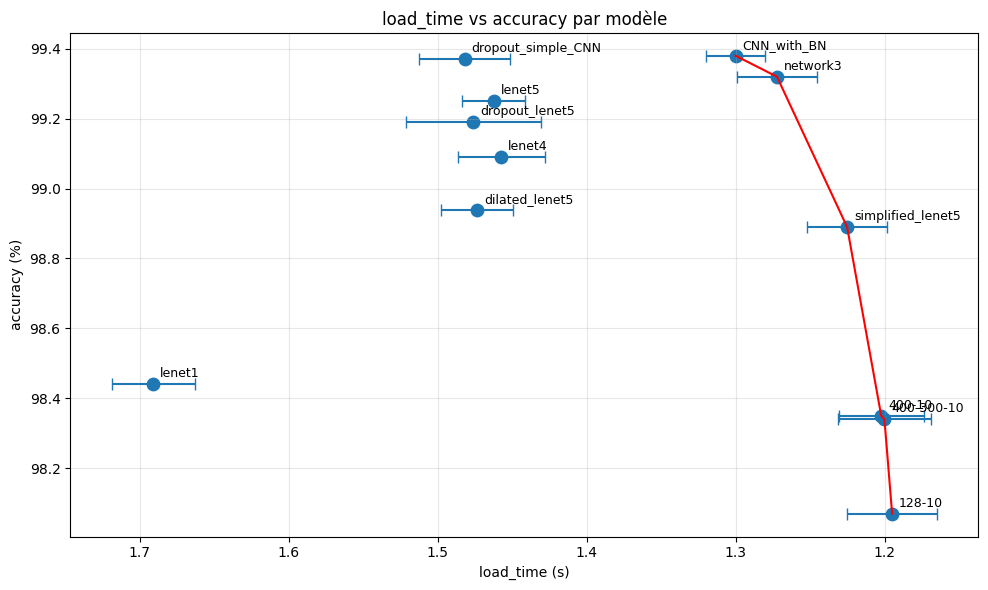

In [79]:
plot_time_vs_accuracy("load_time")

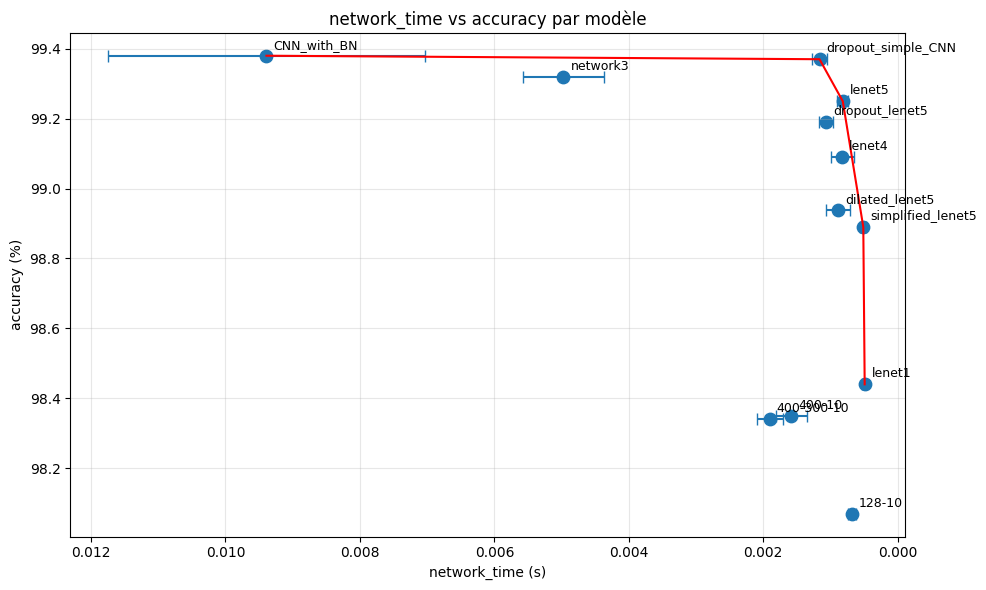

In [80]:
plot_time_vs_accuracy("network_time")

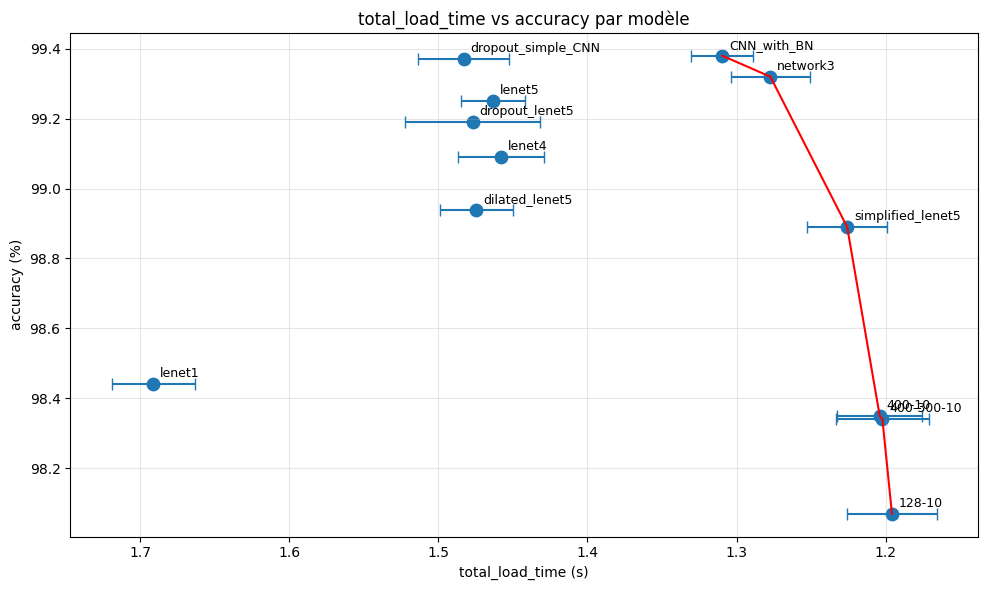

In [81]:
plot_time_vs_accuracy("total_load_time")

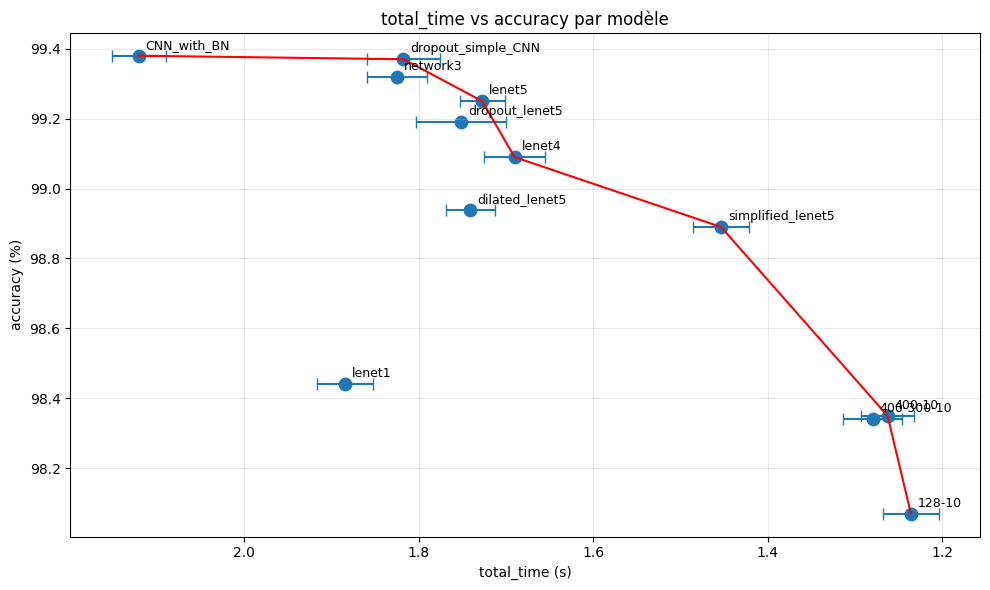

In [82]:
plot_time_vs_accuracy("total_time")

Classement des réseaux par temps

In [83]:
network_time_sorted = df_means.sort_values('network_time', ascending=True).index.tolist()
forward_time_sorted = df_means.sort_values('forward_time', ascending=True).index.tolist()
load_time_sorted = df_means.sort_values('load_time', ascending=True).index.tolist()

ranking_df = pd.DataFrame({
    'Rang': range(1, 13),
    'Network Time': network_time_sorted,
    'Forward Time': forward_time_sorted,
    'Load Time': load_time_sorted
})

def style_dataframe(df):
    
    unique_names = set(df['Network Time'].tolist() + df['Forward Time'].tolist() + df['Load Time'].tolist())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_names)))
    color_map = {name: mcolors.to_hex(color) for name, color in zip(sorted(unique_names), colors)}
    
    # Fonction pour appliquer les couleurs
    def apply_colors(val):
        if val == 'Rang':
            return 'background-color: #f0f0f0'
        if pd.isna(val):
            return ''
        hex_color = color_map.get(val, '#ffffff')
        return f'background-color: {hex_color}; color: black; font-weight: bold'
    
    styled = df.style.map(apply_colors)
    styled.set_properties(**{'text-align': 'center', 'padding': '8px'})
    
    return styled

style_dataframe(ranking_df)

,Rang,Network Time,Forward Time,Load Time
0,1,lenet1,128-10,128-10
1,2,simplified_lenet5,400-10,400-300-10
2,3,128-10,400-300-10,400-10
3,4,lenet5,lenet1,simplified_lenet5
4,5,lenet4,simplified_lenet5,network3
5,6,dilated_lenet5,lenet4,CNN_with_BN
6,7,dropout_lenet5,lenet5,lenet4
7,8,dropout_simple_CNN,dilated_lenet5,lenet5
8,9,400-10,dropout_lenet5,dilated_lenet5
9,10,400-300-10,dropout_simple_CNN,dropout_lenet5


In [84]:
def precision_recall_par_classe(conf_matrix):

    precisions = []
    recalls = []
    n_classes = len(conf_matrix)
    
    for i in range(n_classes):
        # True Positive
        tp = conf_matrix[i][i]

        # False Negative
        fn = sum(conf_matrix[i]) - tp

        # False Positive
        fp = sum(conf_matrix[j][i] for j in range(n_classes)) - tp

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)

        precisions.append(precision)
        recalls.append(recall)
    
    return precisions, recalls

In [104]:
def plot_precision_recall_hitmap(cm_series, vmin, vmax):

    resultats = []

    for net_name, cm in cm_series.items():
        precision, recall = precision_recall_par_classe(cm)

        for classe in range(10):
            resultats.append({
                "Modele": net_name,
                "Classe": classe,
                "Precision": precision[classe],
                "Recall": recall[classe]
            })

    df = pd.DataFrame(resultats)

    pivot_precision = df.pivot(
        index="Classe",
        columns="Modele",
        values="Precision"
    )

    pivot_recall = df.pivot(
        index="Classe",
        columns="Modele",
        values="Recall"
    )


    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ----- Precision -----
    im2 = axes[0].imshow(pivot_precision, vmin=vmin, vmax=vmax, aspect='auto')
    fig.colorbar(im2, ax=axes[0], label="Precision")

    axes[0].set_xticks(range(len(pivot_precision.columns)))
    axes[0].set_xticklabels(
        pivot_precision.columns,
        rotation=60
    )

    axes[0].set_yticks(range(10))
    axes[0].set_yticklabels(range(10))

    axes[0].set_xlabel("Modèles")
    axes[0].set_ylabel("Classe")
    axes[0].set_title("Precision par classe et par modèle")

    # ----- Recall -----
    im1 = axes[1].imshow(pivot_recall, vmin=vmin, vmax=vmax, aspect='auto')
    fig.colorbar(im1, ax=axes[1], label="Recall")

    axes[1].set_xticks(range(len(pivot_recall.columns)))
    axes[1].set_xticklabels(
        pivot_recall.columns,
        rotation=60
    )

    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels(range(10))

    axes[1].set_xlabel("Modèles")
    axes[1].set_ylabel("Classe")
    axes[1].set_title("Recall par classe et par modèle")

    # Ajuste automatiquement l'espacement
    plt.tight_layout()

    # Affichage final
    plt.show()

In [105]:
df_standard = pd.read_csv("created_files/results_standard.csv")
df_standard["confusion_matrix"] = df_standard["confusion_matrix"].apply(ast.literal_eval)
df_standard = df_standard.set_index("net_name")
df_standard

,network_time,test_data_time,forward_time,load_time,accuracy,confusion_matrix
net_name,,,,,,
network3,0.026343,0.040965,0.730075,1.322202,99.32,"[[978, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 1132, 1..."
CNN_with_BN,0.010292,0.005257,0.843492,1.128347,99.38,"[[979, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1134, 0..."
dropout_simple_CNN,0.001277,0.005817,0.339490,1.319072,99.37,"[[975, 0, 1, 0, 0, 0, 3, 1, 0, 0], [0, 1133, 0..."
dropout_lenet5,0.001235,0.005640,0.284503,1.296801,99.19,"[[978, 0, 0, 0, 0, 0, 0, 1, 1, 0], [0, 1131, 0..."
lenet5,0.000686,0.005935,0.300282,1.429869,99.25,"[[975, 0, 0, 0, 0, 0, 2, 2, 1, 0], [1, 1130, 0..."
lenet4,0.000798,0.005605,0.244551,1.299257,99.09,"[[977, 0, 0, 0, 0, 0, 1, 1, 1, 0], [1, 1132, 0..."
simplified_lenet5,0.000898,0.004651,0.251220,1.063913,98.89,"[[976, 1, 0, 0, 0, 0, 1, 0, 2, 0], [0, 1125, 1..."
dilated_lenet5,0.000669,0.005765,0.276190,1.310063,98.94,"[[975, 0, 0, 0, 0, 0, 1, 1, 3, 0], [0, 1130, 1..."
lenet1,0.000434,0.005762,0.200938,1.485375,98.44,"[[971, 1, 0, 0, 0, 2, 3, 1, 0, 2], [0, 1126, 1..."


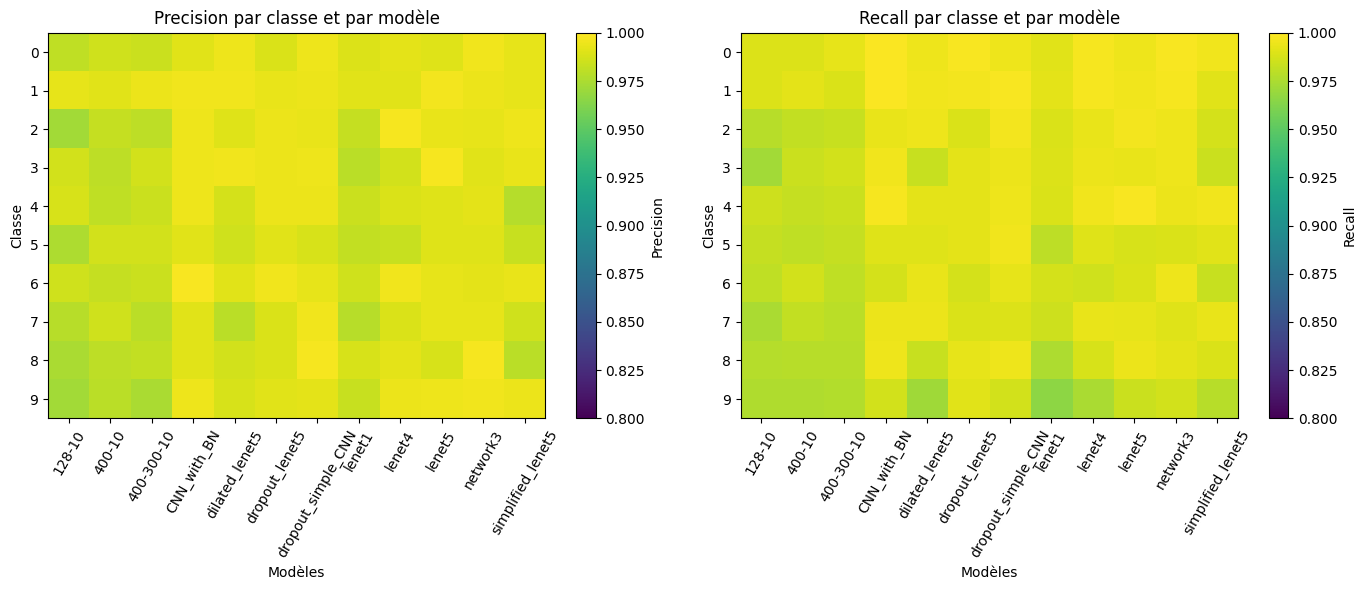

In [107]:
plot_precision_recall_hitmap(df_standard["confusion_matrix"], vmin = 0.8, vmax = 1.0)

Etude de robustesse

In [22]:
df2 = pd.read_json("created_files/accuracies_rotation_robustesse.json")

In [23]:
df2 = df2.T

In [24]:
df2

,0,5,10,15,20,25,30,35
network3,99.32,99.20,98.99,98.64,98.16,97.26,95.85,93.87
CNN_with_BN,99.38,99.37,98.98,98.72,98.08,96.82,94.90,92.99
dropout_simple_CNN,99.37,99.27,99.03,98.71,98.22,97.28,95.96,93.71
dropout_lenet5,99.19,99.13,99.08,98.67,98.10,97.19,95.57,93.43
lenet5,99.25,99.15,98.86,98.54,98.00,96.97,95.41,92.94
lenet4,99.09,98.93,98.72,98.32,97.72,96.73,95.26,93.35
simplified_lenet5,98.89,98.81,98.55,98.06,97.32,96.36,95.08,92.73
dilated_lenet5,98.94,98.83,98.54,98.04,97.30,95.99,93.69,90.95
lenet1,98.44,98.20,97.95,97.39,96.58,95.11,93.01,90.07
400-300-10,98.34,98.31,97.82,97.06,95.94,94.13,91.64,87.77


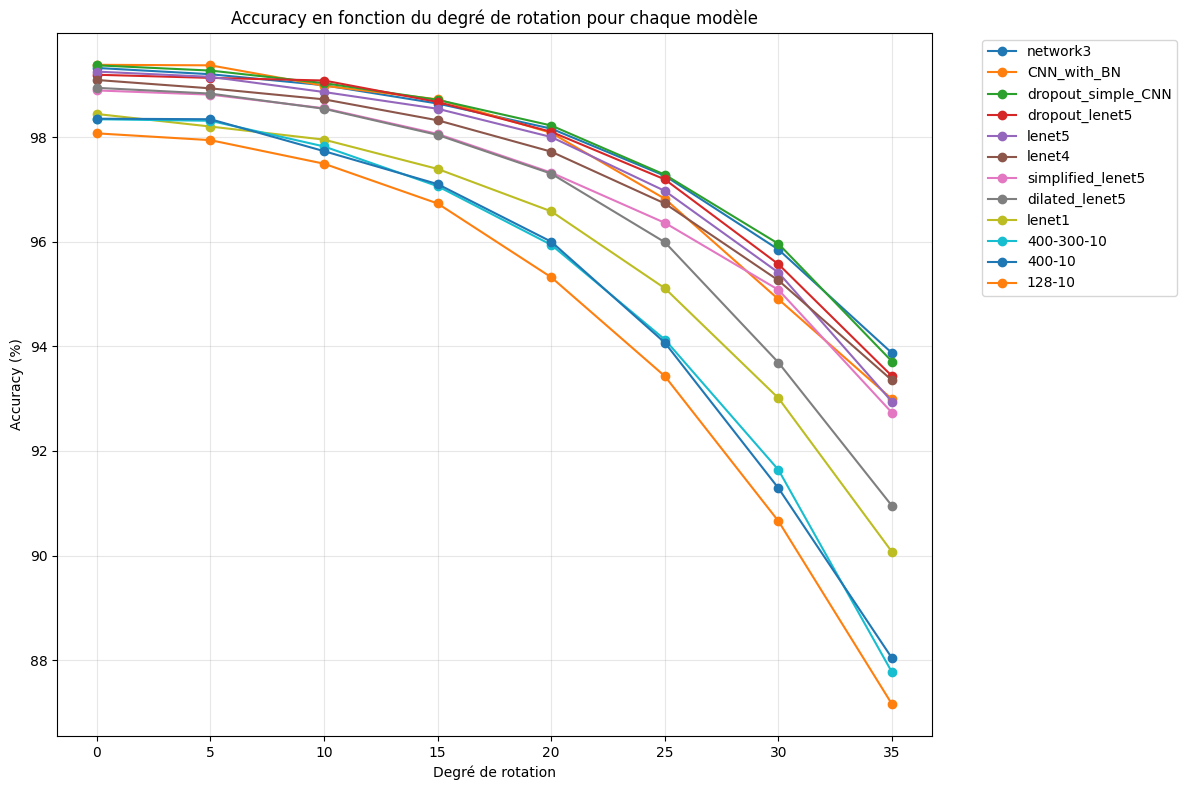

In [25]:
plt.figure(figsize=(12, 8))
angles = df2.columns.astype(float)
for model in df2.index:
    plt.plot(angles, df2.loc[model].values, marker='o', label=model)

plt.xlabel('Degré de rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction du degré de rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Les réseaux les plus pertinents semblent être :

network3,

dropout_simple_CNN,

dropout_lenet5,

lenet4,

CNN_with_BN,

lenet5,

simplified_lenet5.

In [26]:
df3 = pd.read_json("created_files/accuracies_translation_robustesse.json", convert_axes=False)

In [27]:
df3 = df3.T

In [28]:
df3

,0.0,0.02,0.04,0.06,0.08,0.1,0.12,0.14
network3,99.32,99.24,98.77,97.79,95.98,91.94,86.74,79.07
CNN_with_BN,99.38,99.26,98.86,98.07,96.35,92.10,86.92,79.16
dropout_simple_CNN,99.37,99.32,98.59,97.51,94.88,89.96,84.23,75.72
dropout_lenet5,99.19,99.11,98.78,98.10,96.45,92.92,88.22,80.75
lenet5,99.25,99.18,98.53,97.43,94.96,90.64,85.16,76.88
lenet4,99.09,98.91,98.35,97.31,94.93,90.56,84.94,76.16
simplified_lenet5,98.89,98.77,98.19,97.04,94.65,89.88,84.41,76.10
dilated_lenet5,98.94,98.71,97.89,96.82,94.27,89.47,84.27,76.20
lenet1,98.44,98.41,97.85,96.78,94.40,90.34,85.89,78.99
400-300-10,98.34,97.97,96.39,93.00,86.65,78.13,69.24,58.90


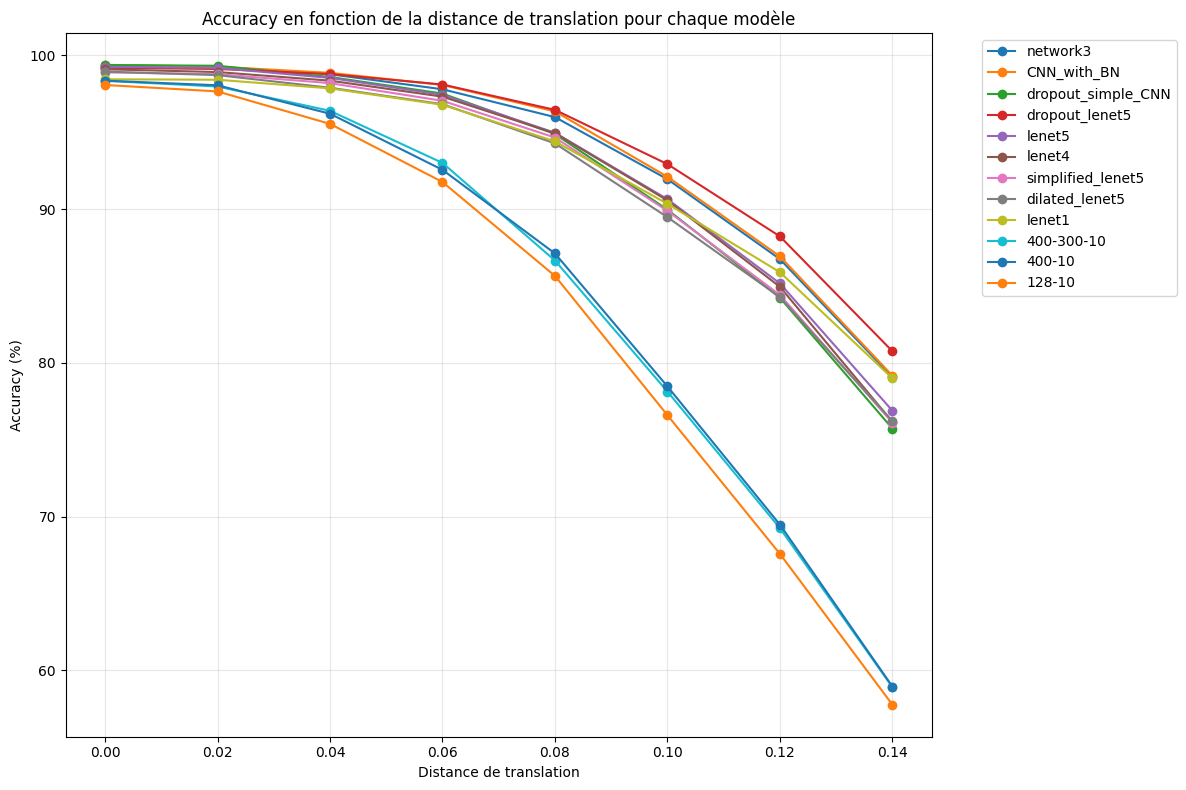

In [29]:
plt.figure(figsize=(12, 8))
angles = df3.columns.astype(float)
for model in df3.index:
    plt.plot(angles, df3.loc[model].values, marker='o', label=model)

plt.xlabel('Distance de translation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction de la distance de translation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Les réseaux les plus pertinents semblent être :

dropout_lenet5,

CNN_with_BN,

network3,

lenet1,

lenet5,

lenet4,

dilated_lenet5,

simplified_lenet5,

dropout_simple_CNN.

In [11]:
df_test_list_affine = pd.read_csv("created_files/results_test_list_affine.csv")

In [12]:
df_test_list_affine

,net_name,network_time,test_data_time,forward_time,load_time,accuracy,confusion_matrix
0,network3,0.004432,1.333618,0.472952,0.092747,99.32,"[[978, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 1132, 1..."
1,CNN_with_BN,0.008309,1.374330,0.758628,0.106080,99.38,"[[979, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1134, 0..."
2,dropout_simple_CNN,0.001333,1.459467,0.254791,0.086268,99.37,"[[975, 0, 1, 0, 0, 0, 3, 1, 0, 0], [0, 1133, 0..."
3,dropout_lenet5,0.000912,1.524061,0.184439,0.079551,99.19,"[[978, 0, 0, 0, 0, 0, 0, 1, 1, 0], [0, 1131, 0..."
4,lenet5,0.000999,1.545873,0.176417,0.082790,99.25,"[[975, 0, 0, 0, 0, 0, 2, 2, 1, 0], [1, 1130, 0..."
...,...,...,...,...,...,...,...
91,dilated_lenet5,0.000704,1.445321,0.173042,0.071046,50.72,"[[366, 31, 109, 22, 50, 82, 121, 58, 74, 67], ..."
92,lenet1,0.000409,1.655863,0.109694,0.064121,54.87,"[[437, 66, 82, 32, 91, 63, 75, 41, 41, 52], [1..."
93,400-300-10,0.001664,1.287461,0.047656,0.062442,36.18,"[[271, 34, 120, 108, 71, 97, 70, 60, 72, 77], ..."
94,400-10,0.001211,1.280527,0.034314,0.064102,36.09,"[[261, 67, 134, 100, 62, 104, 66, 82, 47, 57],..."


In [13]:
nb_nets = 12
accuracy_list = [df_test_list_affine["accuracy"].iloc[i * nb_nets : (i + 1) * nb_nets].tolist() for i in range(8)]

df_accuracies_affine = pd.DataFrame(accuracy_list).T

model_names = df_test_list_affine["net_name"].iloc[:nb_nets].tolist()
df_accuracies_affine.index = model_names
df_accuracies_affine.index.name = "net_name"

df_accuracies_affine.columns = [(round(i * 0.03, 2), i * 5) for i in range(df_accuracies_affine.shape[1])]


In [39]:
df_accuracies_affine

,"(0.0, 0)","(0.03, 5)","(0.06, 10)","(0.09, 15)","(0.12, 20)","(0.15, 25)","(0.18, 30)","(0.21, 35)"
net_name,,,,,,,,
network3,99.32,99.24,98.49,96.11,89.51,78.70,66.57,53.36
CNN_with_BN,99.38,99.32,98.52,96.18,89.13,77.63,65.33,52.60
dropout_simple_CNN,99.37,99.27,98.54,95.68,88.03,76.59,63.44,51.16
dropout_lenet5,99.19,99.10,98.53,96.31,90.83,81.38,69.42,56.89
lenet5,99.25,99.15,98.07,95.50,87.58,78.17,64.02,52.06
lenet4,99.09,98.94,97.94,95.24,88.14,77.49,65.11,52.42
simplified_lenet5,98.89,98.86,98.04,94.98,88.48,77.68,63.96,52.11
dilated_lenet5,98.94,98.82,97.98,93.96,86.90,75.80,63.74,50.72
lenet1,98.44,98.27,97.27,94.30,87.64,78.32,66.68,54.87


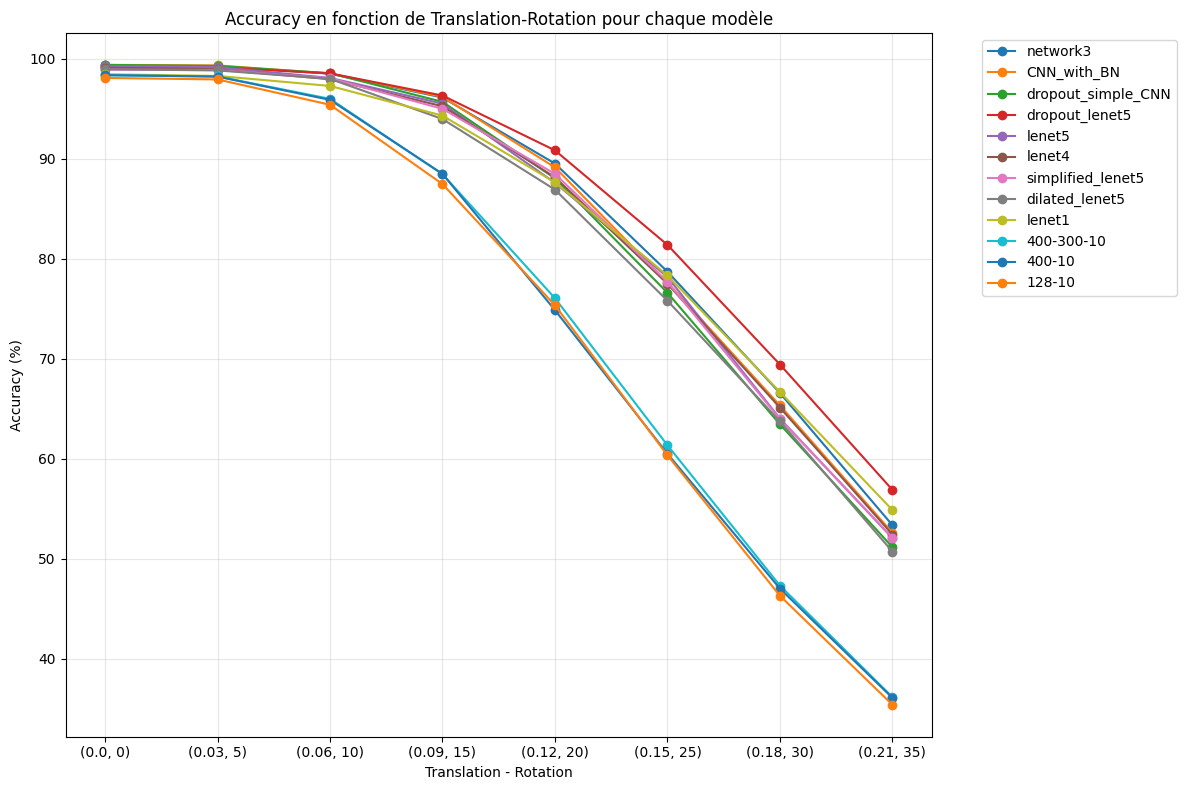

In [18]:
plt.figure(figsize=(12, 8))
tuples = [str(t) for t in df_accuracies_affine.columns]
for model in df_accuracies_affine.index:
    plt.plot(tuples, df_accuracies_affine.loc[model].values, marker='o', label=model)

plt.xlabel('Translation - Rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction de Translation-Rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_test_list_affine = df_test_list_affine.set_index("net_name")

In [113]:
nb_nets = 12
list_df_affine = []
for i in range (8):
    list_df_affine.append(df_test_list_affine.iloc[i*nb_nets : (i+1)*nb_nets])

transformations : (0.0, 0)


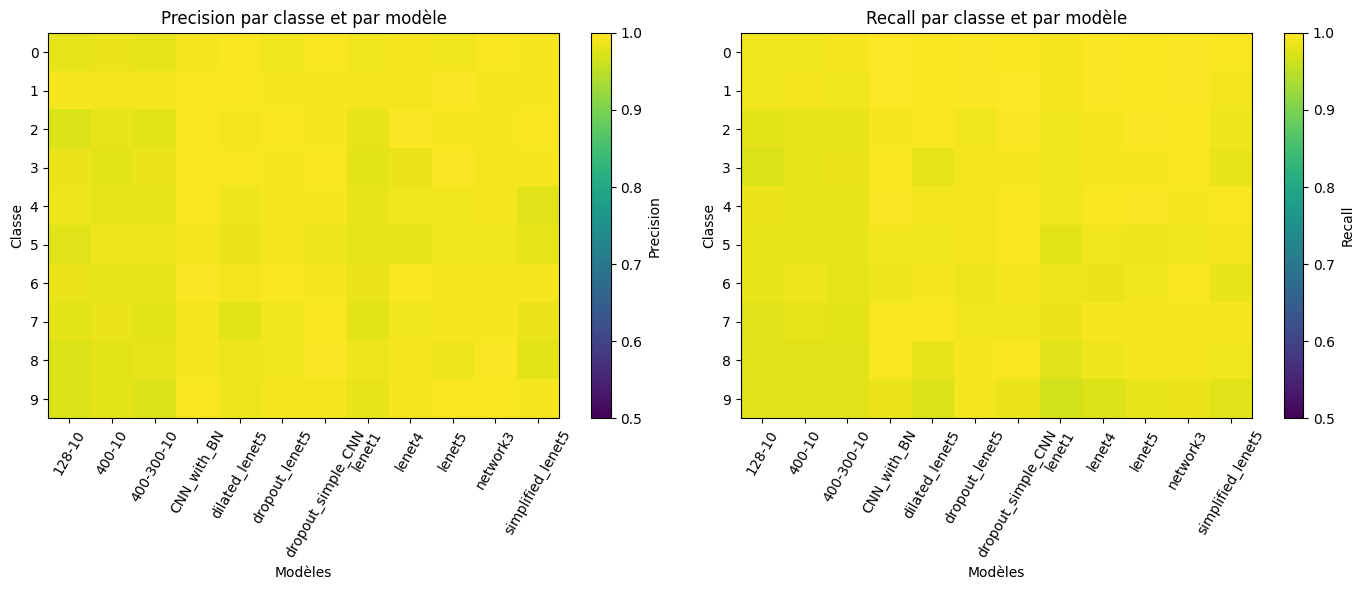

In [144]:
print(f"transformations : {df_accuracies_affine.columns[0]}")
plot_precision_recall_hitmap(list_df_affine[0]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.12, 20)


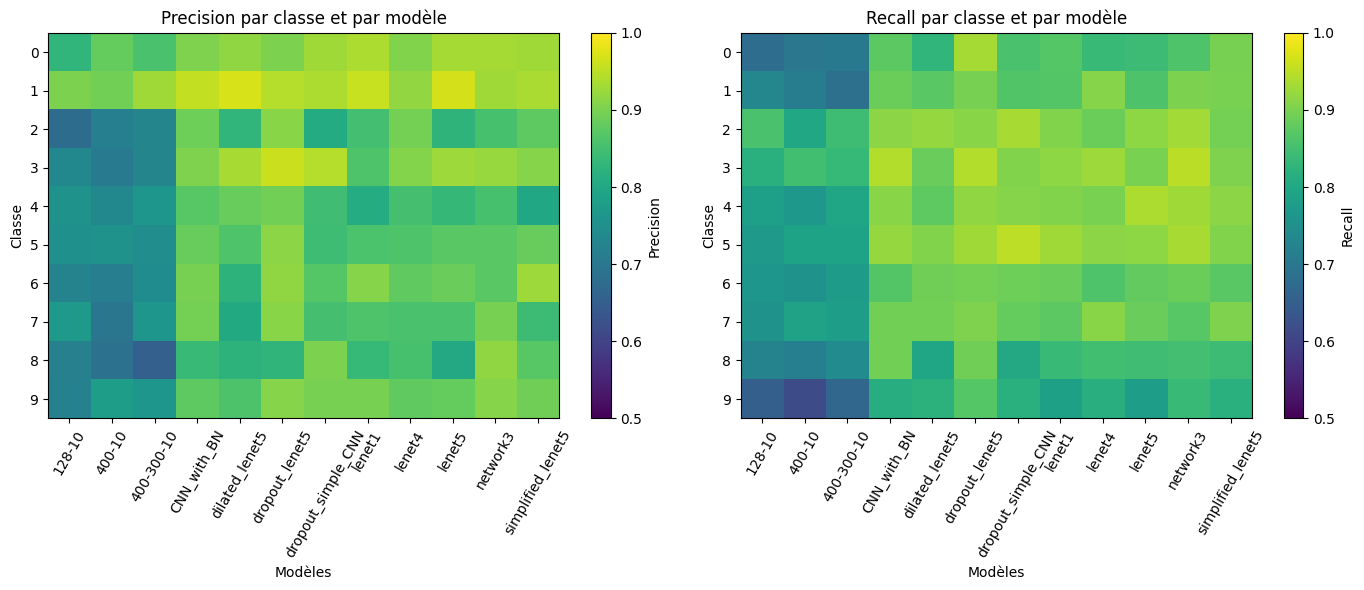

In [145]:
print(f"transformations : {df_accuracies_affine.columns[4]}")
plot_precision_recall_hitmap(list_df_affine[4]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.21, 35)


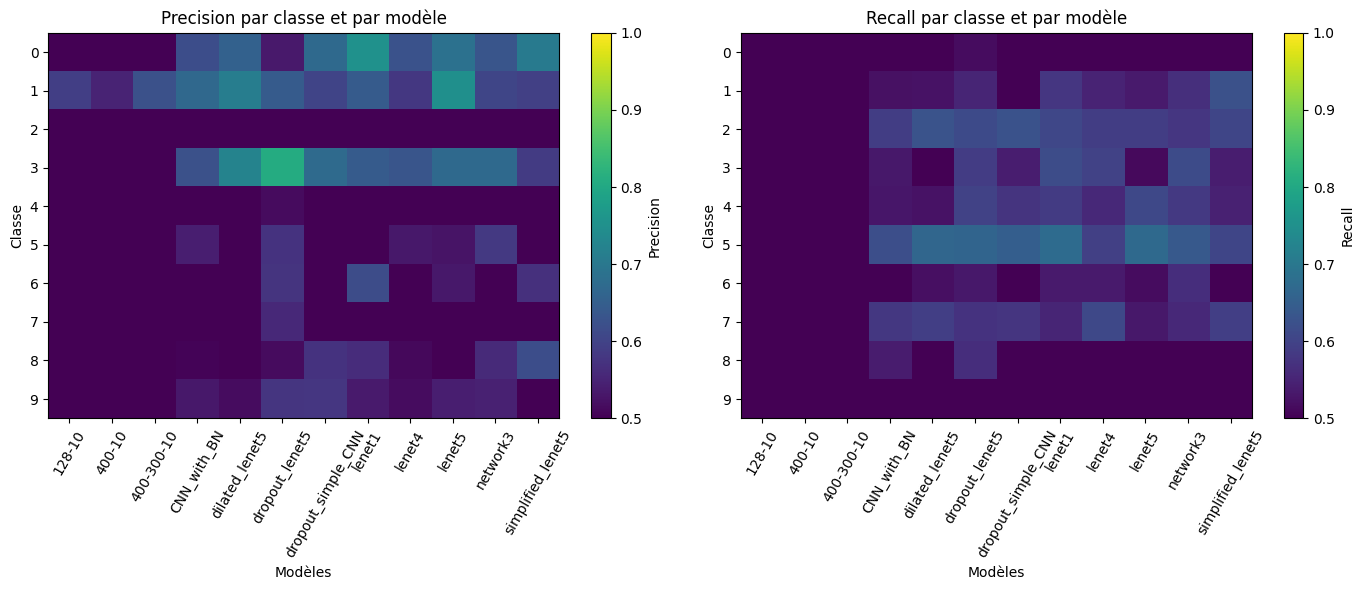

In [146]:
print(f"transformations : {df_accuracies_affine.columns[7]}")
plot_precision_recall_hitmap(list_df_affine[7]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

Tests des réseaux de neurones entraînés avec data augmentation

In [121]:
df_test_list_affine_trained = pd.read_csv("created_files/results_test_list_affine_trained.csv")

In [122]:
df_test_list_affine_trained

,net_name,network_time,test_data_time,forward_time,load_time,accuracy,confusion_matrix
0,network3,0.004776,1.328456,0.481379,0.096215,98.57,"[[972, 0, 1, 0, 0, 0, 4, 0, 3, 0], [0, 1127, 3..."
1,CNN_with_BN,0.011872,1.316748,0.768479,0.103757,98.95,"[[978, 0, 1, 0, 0, 0, 1, 0, 0, 0], [0, 1130, 4..."
2,dropout_simple_CNN,0.001178,1.465383,0.263536,0.087238,98.38,"[[970, 0, 4, 0, 2, 0, 2, 0, 2, 0], [1, 1116, 4..."
3,dropout_lenet5,0.000913,1.477864,0.184116,0.074663,97.98,"[[974, 0, 0, 0, 0, 0, 4, 1, 1, 0], [2, 1122, 4..."
4,lenet5,0.000725,1.531955,0.189409,0.080913,98.80,"[[971, 0, 3, 0, 1, 0, 4, 0, 0, 1], [0, 1129, 1..."
...,...,...,...,...,...,...,...
91,dilated_lenet5,0.000889,1.501634,0.169651,0.069887,97.36,"[[971, 0, 0, 0, 0, 1, 2, 5, 1, 0], [0, 1129, 1..."
92,lenet1,0.000462,1.669601,0.134018,0.082722,94.28,"[[950, 0, 3, 3, 2, 1, 8, 3, 8, 2], [3, 1111, 4..."
93,400-300-10,0.002207,1.289230,0.051650,0.067859,96.16,"[[968, 0, 1, 1, 0, 2, 5, 0, 2, 1], [0, 1120, 2..."
94,400-10,0.001644,1.294133,0.036721,0.063835,93.48,"[[955, 0, 4, 0, 2, 5, 3, 2, 9, 0], [0, 1111, 3..."


In [124]:
nb_nets = 12
accuracy_list = [df_test_list_affine_trained["accuracy"].iloc[i * nb_nets : (i + 1) * nb_nets].tolist() for i in range(8)]

df_accuracies_affine_trained = pd.DataFrame(accuracy_list).T

model_names = df_test_list_affine_trained["net_name"].iloc[:nb_nets].tolist()
df_accuracies_affine_trained.index = model_names
df_accuracies_affine_trained.index.name = "net_name"

df_accuracies_affine_trained.columns = [(round(i * 0.03, 2), i * 5) for i in range(df_accuracies_affine_trained.shape[1])]

In [125]:
df_accuracies_affine_trained

,"(0.0, 0)","(0.03, 5)","(0.06, 10)","(0.09, 15)","(0.12, 20)","(0.15, 25)","(0.18, 30)","(0.21, 35)"
net_name,,,,,,,,
network3,98.57,98.52,98.43,98.38,98.35,98.11,97.97,97.47
CNN_with_BN,98.95,98.85,98.76,98.70,98.69,98.48,98.27,97.83
dropout_simple_CNN,98.38,98.29,98.19,97.93,98.02,97.91,97.54,96.98
dropout_lenet5,97.98,97.82,97.81,97.88,97.70,97.54,97.66,96.88
lenet5,98.80,98.68,98.57,98.69,98.33,98.43,98.19,97.70
lenet4,98.20,98.18,98.26,98.03,97.98,97.72,97.63,97.11
simplified_lenet5,97.36,97.22,96.73,96.65,96.53,96.28,95.87,94.87
dilated_lenet5,98.36,98.17,98.05,98.13,97.95,97.99,97.48,97.36
lenet1,96.52,96.37,96.20,96.08,95.90,95.59,95.29,94.28


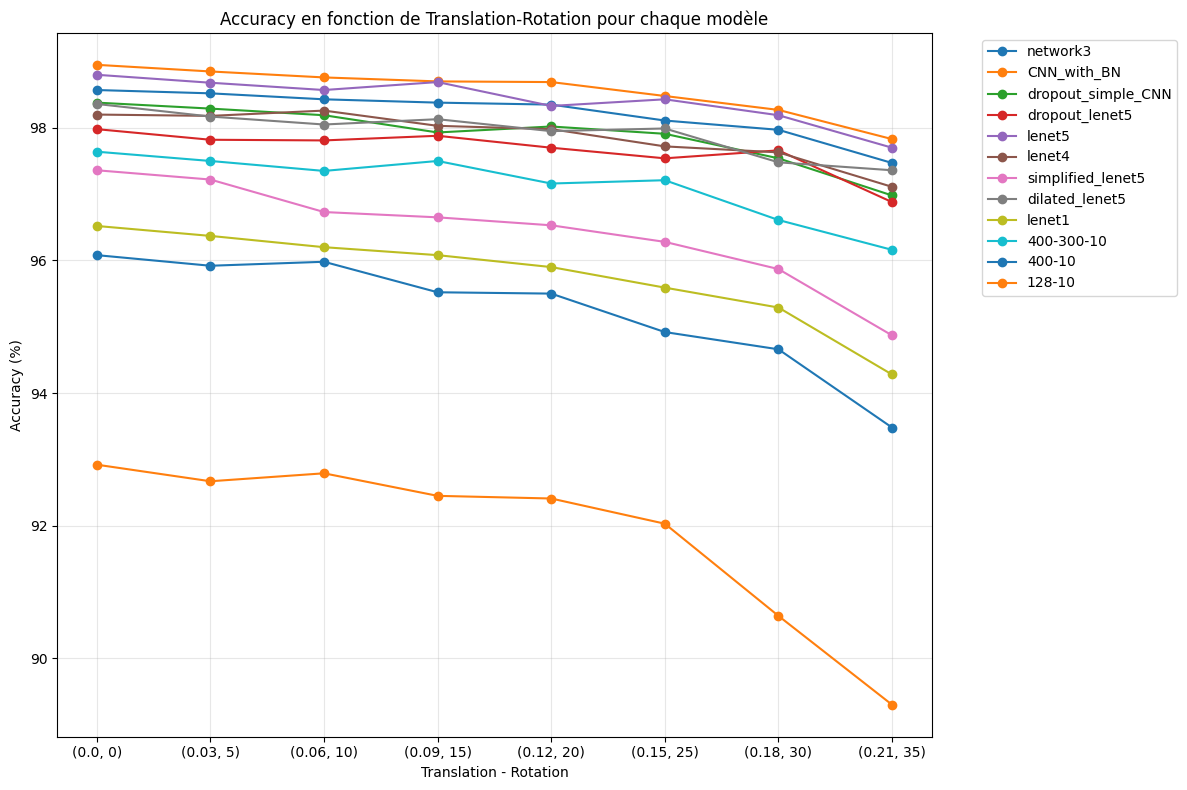

In [126]:
plt.figure(figsize=(12, 8))
tuples = [str(t) for t in df_accuracies_affine_trained.columns]
for model in df_accuracies_affine_trained.index:
    plt.plot(tuples, df_accuracies_affine_trained.loc[model].values, marker='o', label=model)

plt.xlabel('Translation - Rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction de Translation-Rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [127]:
df_test_list_affine_trained["confusion_matrix"] = df_test_list_affine_trained["confusion_matrix"].apply(ast.literal_eval)
df_test_list_affine_trained = df_test_list_affine_trained.set_index("net_name")

In [128]:
nb_nets = 12
df_list = []
for i in range (8):
    df_list.append(df_test_list_affine_trained.iloc[i*nb_nets : (i+1)*nb_nets])

transformations : (0.0, 0)


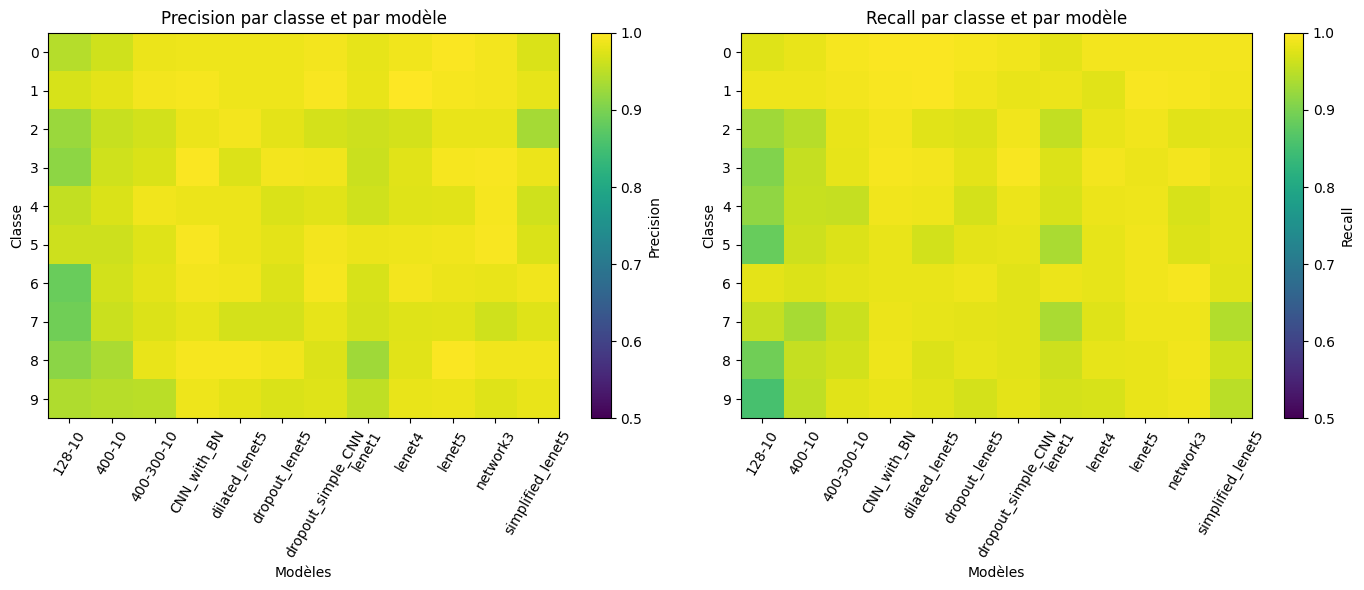

In [141]:
print(f"transformations : {df_accuracies_affine_trained.columns[0]}")
plot_precision_recall_hitmap(df_list[0]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.12, 20)


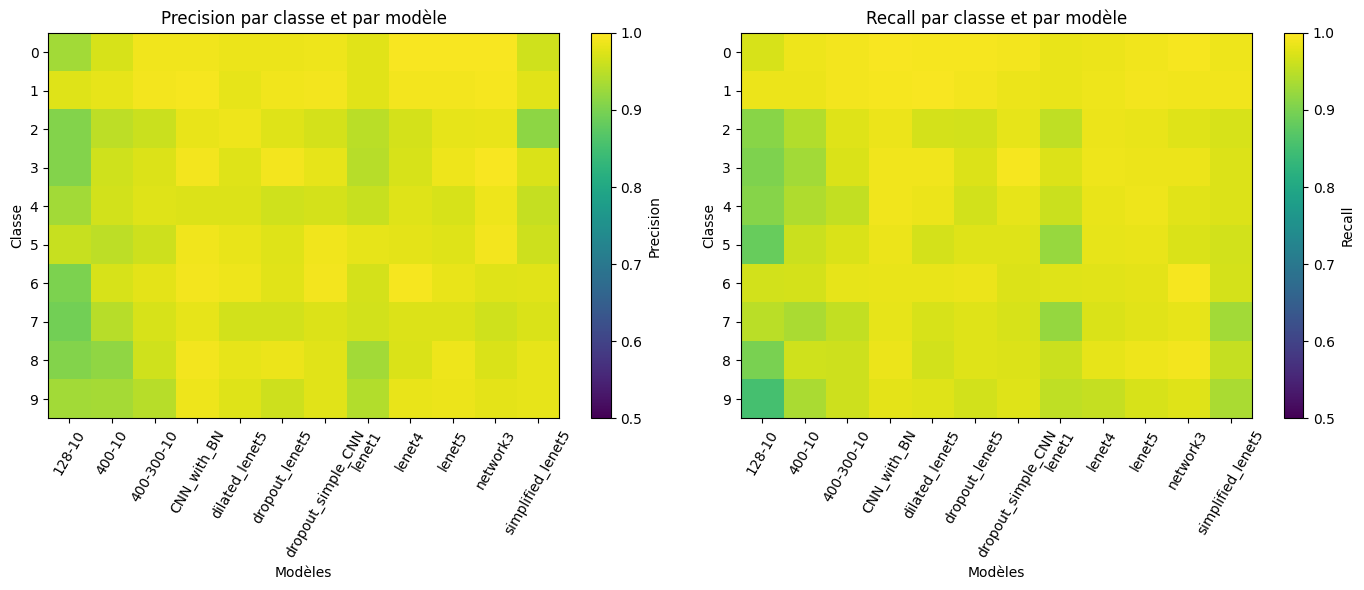

In [142]:
print(f"transformations : {df_accuracies_affine_trained.columns[4]}")
plot_precision_recall_hitmap(df_list[4]["confusion_matrix"], vmin = 0.5, vmax = 1.0)

transformations : (0.21, 35)


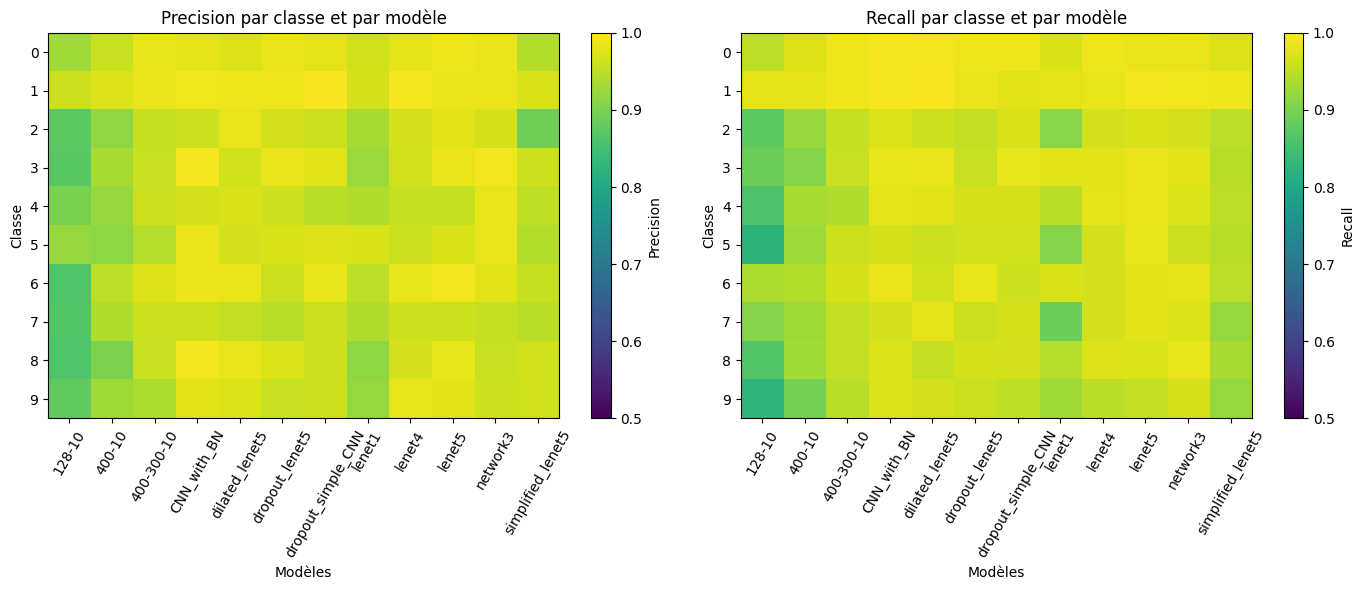

In [143]:
print(f"transformations : {df_accuracies_affine_trained.columns[7]}")
plot_precision_recall_hitmap(df_list[7]["confusion_matrix"], vmin = 0.5, vmax = 1.0)